In [2]:
# Suppress warnings to keep the notebook output clean
import warnings
warnings.filterwarnings('ignore')

# Import necessary packages
import matplotlib
matplotlib.use('Agg')  # Ensures matplotlib uses the 'Agg' backend

import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # In case only plt is imported
%matplotlib inline

import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Set some plot styles
sns.set(style='whitegrid')

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("brandmustafa/college-marks-dataset-2025")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'college-marks-dataset-2025' dataset.
Path to dataset files: /kaggle/input/college-marks-dataset-2025


Data Loading

In [11]:
# Load the College Marks Dataset
file_path = '/kaggle/input/college-marks-dataset-2025/College_Marks_Dataset.csv'

try:
    df = pd.read_csv(file_path, delimiter=',', encoding='ascii')
    print('Data loaded successfully.')
except Exception as e:
    print('Error loading data. Please check the file path and file format.')
    print(e)

Data loaded successfully.


Data Exploration

In [12]:
# Display the first few rows
print('First 5 rows of the dataset:')
print(df.head())

# Display dataset information
print('\nDataset Information:')
print(df.info())

# Summary statistics for numeric columns
print('\nSummary Statistics:')
print(df.describe())

First 5 rows of the dataset:
  Student_ID       Name     Class  SSC_Marks  HSC_Marks  College_Marks  \
0      S1000  Student_0  Commerce        535        452            692   
1      S1001  Student_1  Commerce        494        535            551   
2      S1002  Student_2   Science        542        460            634   
3      S1003  Student_3   Science        441        483            686   
4      S1004  Student_4      Arts        427        544            569   

   Attendance_Percentage Grade  
0                  84.71     C  
1                  81.99     D  
2                  92.06     B  
3                  79.27     D  
4                  91.99    A+  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             1000 non-null   object 
 1   Name                   1000 non-null   o

Data Cleaning and Preprocessing

In [13]:
# Check for missing values
print('Missing values in each column:')
print(df.isnull().sum())

# If missing values are found, fill or drop as appropriate
# For this dataset, we assume that there are no critical missing values.

# Convert columns if necessary (for example, ensure numeric columns are correctly typed)
numeric_columns = ['SSC_Marks', 'HSC_Marks', 'College_Marks', 'Attendance_Percentage']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# If dates were present and not explicitly provided, we could parse them here.
# (No date columns in this dataset as per the dataset description.)

# As a simple cleaning step, let's strip extra spaces from string columns
string_cols = df.select_dtypes(include=['object']).columns
for col in string_cols:
    df[col] = df[col].str.strip()

print('\nData cleaning complete.')

Missing values in each column:
Student_ID               0
Name                     0
Class                    0
SSC_Marks                0
HSC_Marks                0
College_Marks            0
Attendance_Percentage    0
Grade                    0
dtype: int64

Data cleaning complete.


Visualization Analysis

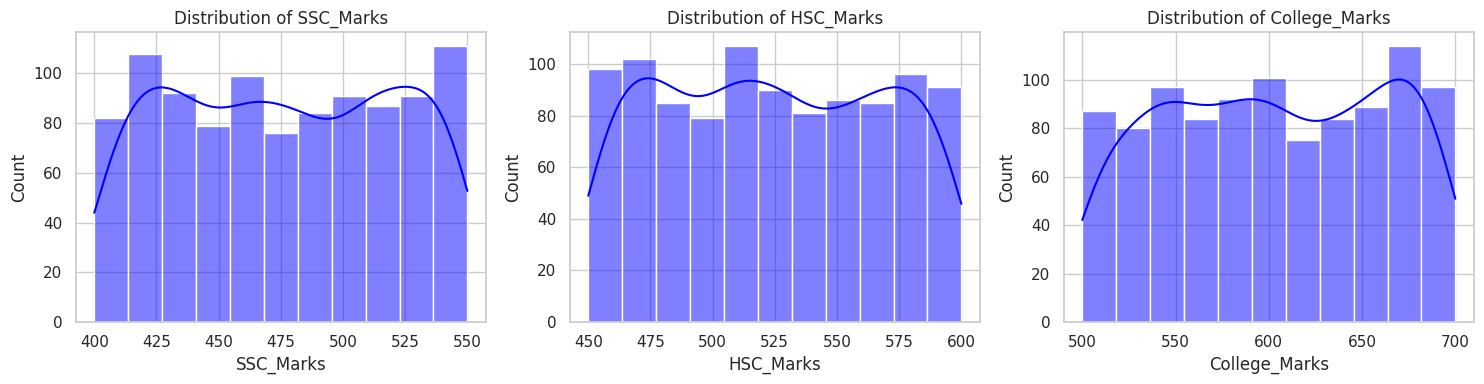

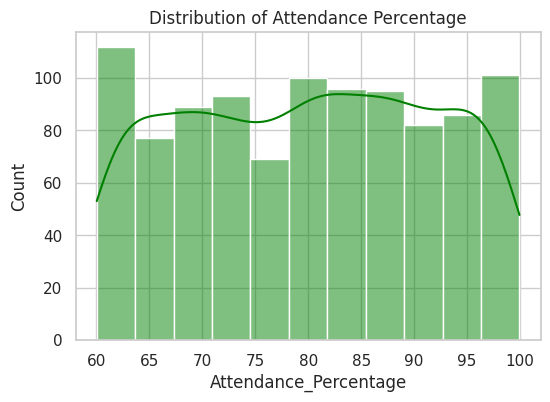

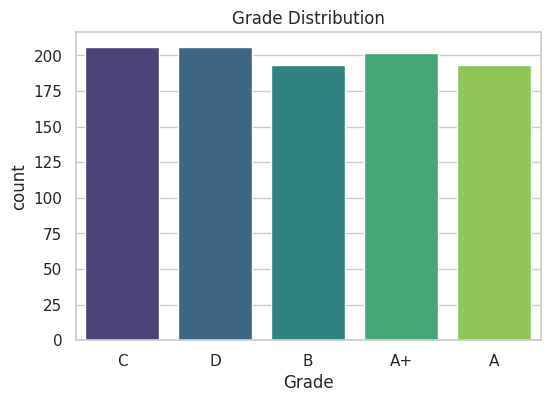

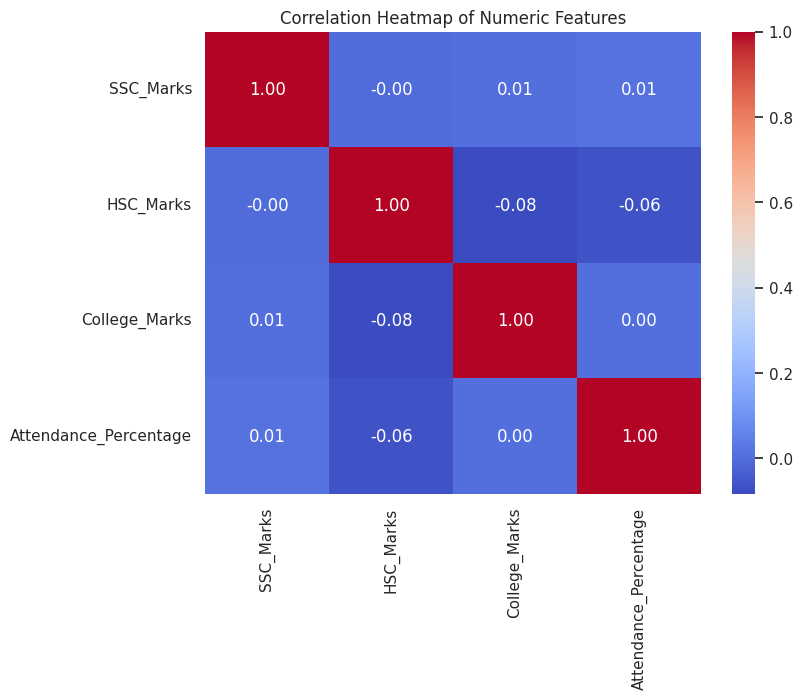

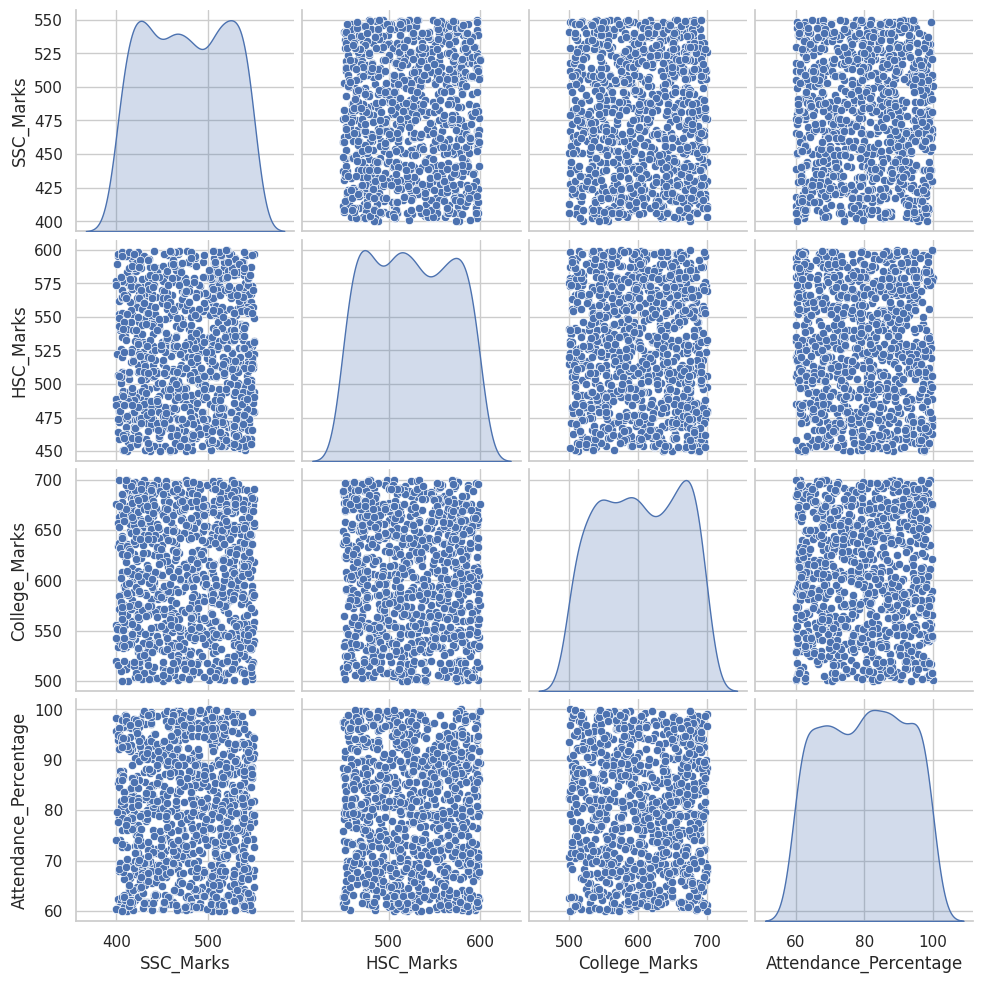

In [14]:
# Visualizations to understand the dataset better

# Distribution of SSC Marks, HSC Marks and College Marks
plt.figure(figsize=(15, 4))
for idx, col in enumerate(['SSC_Marks', 'HSC_Marks', 'College_Marks']):
    plt.subplot(1, 3, idx+1)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Attendance Percentage Histogram
plt.figure(figsize=(6,4))
sns.histplot(df['Attendance_Percentage'], kde=True, color='green')
plt.title('Distribution of Attendance Percentage')
plt.show()

# Count Plot for Grades (Pie Chart style interpretation using countplot)
plt.figure(figsize=(6,4))
sns.countplot(x='Grade', data=df, palette='viridis')
plt.title('Grade Distribution')
plt.show()

# Correlation Heatmap using Numeric Values (only if four or more numeric columns exist)
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(8,6))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()

# Pair Plot to see relationships between numeric features
sns.pairplot(numeric_df, diag_kind='kde')
plt.show()

Predictive Modeling

Accuracy of the Decision Tree Classifier: 0.21


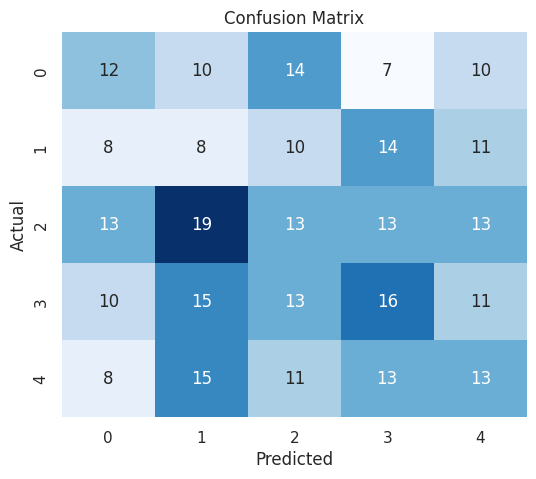

In [15]:
# In this section, we build a predictor to classify students' Grade based on numeric features.

# Prepare the data for modeling
# We use SSC_Marks, HSC_Marks, College_Marks and Attendance_Percentage as features.
features = ['SSC_Marks', 'HSC_Marks', 'College_Marks', 'Attendance_Percentage']
X = df[features]
y = df['Grade']

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Initialize and train a Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Calculate the prediction accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy of the Decision Tree Classifier: {acc:.2f}')

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

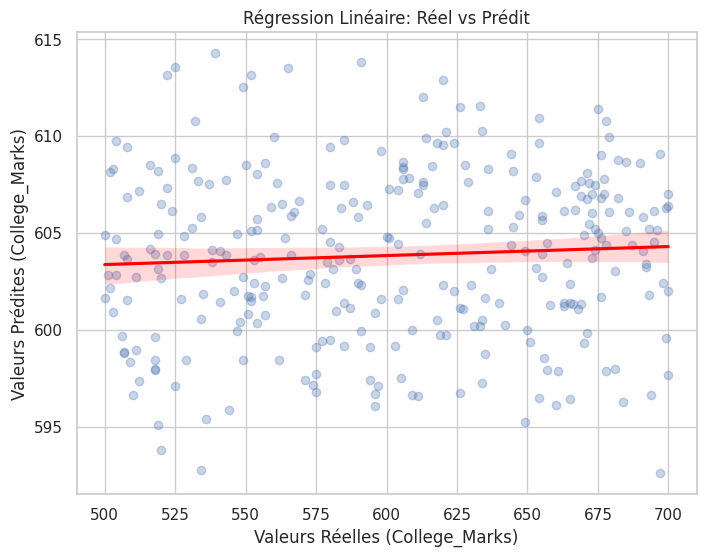

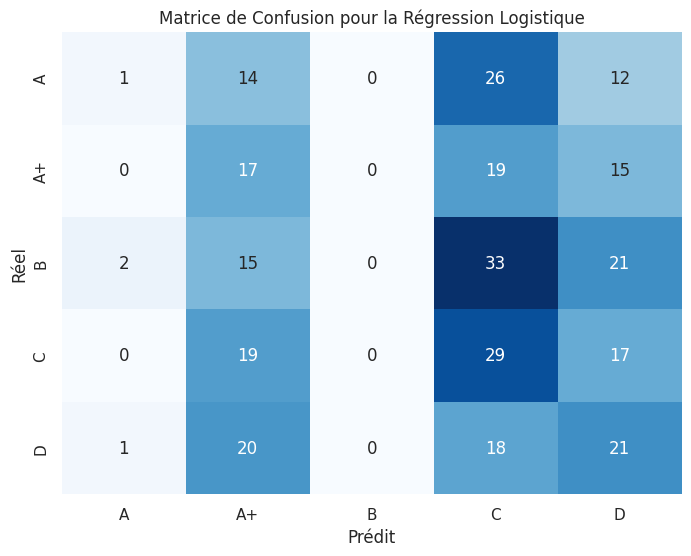

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- Plot for Linear Regression ---
plt.figure(figsize=(8, 6))
sns.regplot(x=y_test_lin, y=y_pred_lin, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Valeurs Réelles (College_Marks)')
plt.ylabel('Valeurs Prédites (College_Marks)')
plt.title('Régression Linéaire: Réel vs Prédit')
plt.grid(True)
plt.show()

# --- Plot for Logistic Regression (Confusion Matrix) ---
plt.figure(figsize=(8, 6))
cm_log = confusion_matrix(y_test_log, y_pred_log)

# Get original grade labels for better readability on the plot
grade_labels = le.inverse_transform(np.unique(y_encoded))

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=grade_labels, yticklabels=grade_labels)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion pour la Régression Logistique')
plt.show()